In [6]:
import pandas as pd
import sacrebleu
import re

def calculate_bleu(reference, candidate):
    """
    Calculate BLEU score between reference and candidate translations using sacrebleu
    """
    # sacrebleu expects a list of references and a single hypothesis
    references = [reference]
    bleu = sacrebleu.sentence_bleu(candidate, references)
    return bleu.score / 100  # Normalize to 0-1 range to match NLTK's output

def evaluate_translations(filename):
    """
    Evaluate translations from a CSV file containing ground truth and generated translations
    """
    # ... existing code ...
    df = pd.read_csv(filename)
    
    bleu_scores = []
    for _, row in df.iterrows():
        bleu = calculate_bleu(row['ground_truth'], row['generated'])
        bleu_scores.append(bleu)
    
    # ... existing code ...
    df['bleu_score'] = bleu_scores
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    
    return avg_bleu

In [2]:
import os
import glob

results = []
for f in glob.glob("./zero-shot/*.csv") + glob.glob("./many-shot/*.csv") + glob.glob("./sft-stage-1/*.csv") + glob.glob("./sft-stage-2/*.csv"):
    avg_bleu = evaluate_translations(f)
    results.append({
        'file': f,
        'avg_bleu': avg_bleu
    })
    print(f"File: {f}, Average BLEU: {avg_bleu}")

# Create results dataframe and save to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("translation_evaluation_results.csv", index=False)

File: ./zero-shot/translation_results_mt5_large_v1.csv, Average BLEU: 0.1553814317850185
File: ./zero-shot/translation_results_llama_3.3_70B.csv, Average BLEU: 0.3631749340948216
File: ./zero-shot/translation_results_cohere_aya_8B.csv, Average BLEU: 0.21306644108185857
File: ./zero-shot/translation_results_llama_405B.csv, Average BLEU: 0.40742659977224455
File: ./zero-shot/translation_results_t5_finetuned_2.csv, Average BLEU: 0.24816537898186156
File: ./zero-shot/translation_results_t5_base.csv, Average BLEU: 0.0464859840735015
File: ./zero-shot/translation_results_o1_mini.csv, Average BLEU: 0.36767716153537866
File: ./zero-shot/translation_results_mt5_large_v1_cleaned.csv, Average BLEU: 0.17471835766027702
File: ./zero-shot/translation_results_gpt_4o.csv, Average BLEU: 0.46704502531431763
File: ./zero-shot/translation_results_t5_finetuned.csv, Average BLEU: 0.14738435761451446
File: ./zero-shot/translation_results_google_mt5_base.csv, Average BLEU: 0.008804714452018575
File: ./zero-sh

### Corpus BLEU

In [3]:
from sacrebleu import corpus_bleu, corpus_chrf, corpus_ter

# reimplement above flow but use corpus level bleu instead of averaging sentence scores
def evaluate_corpus(filename):
    """
    Evaluate translations using corpus-level BLEU score instead of averaging sentence-level scores
    """
    df = pd.read_csv(filename)
    
    # Collect all translations and references
    candidates = df['generated'].tolist()
    references = [df['ground_truth'].tolist()]  # Corpus BLEU expects list of reference lists
    
    # Calculate corpus-level BLEU
    corpus_bleu_score = corpus_bleu(candidates, references)
    corpus_chrf_score = corpus_chrf(candidates, references)
    corpus_ter_score = corpus_ter(candidates, references)
    return corpus_bleu_score.score / 100, corpus_chrf_score.score /100, corpus_ter_score.score/100  # Normalize to 0-1 range

# Evaluate corpus BLEU for all files
corpus_results = []
for f in glob.glob("./zero-shot/*.csv") + glob.glob("./many-shot/*.csv") + glob.glob("./sft-stage-1/*.csv") + glob.glob("./sft-stage-2/*.csv"):
    corpus_bleu_val, corpus_chrf_val, corpus_ter_val  = evaluate_corpus(f)
    corpus_results.append({
        'file': f,
        'corpus_bleu': corpus_bleu_val,
        'corpus_chrf_score': corpus_chrf_val,
        'corpus_ter_score': corpus_ter_val
    })
    print(f"File: {f}, Corpus BLEU: {corpus_bleu_val}, Corpus ChrF: {corpus_chrf_val}, Corpus TER: {corpus_ter_val}")

# Create corpus results dataframe and save to CSV
corpus_results_df = pd.DataFrame(corpus_results)
corpus_results_df.to_csv("corpus_translation_evaluation_results.csv", index=False)


File: ./zero-shot/translation_results_mt5_large_v1.csv, Corpus BLEU: 0.17563251240822234, Corpus ChrF: 0.39248102634038295, Corpus TER: 0.7213908924534396
File: ./zero-shot/translation_results_llama_3.3_70B.csv, Corpus BLEU: 0.3956276698078195, Corpus ChrF: 0.6733914758628895, Corpus TER: 0.4190978576811283
File: ./zero-shot/translation_results_cohere_aya_8B.csv, Corpus BLEU: 0.22242374434825643, Corpus ChrF: 0.5428674123430136, Corpus TER: 0.6028636021100227
File: ./zero-shot/translation_results_llama_405B.csv, Corpus BLEU: 0.4495233490836049, Corpus ChrF: 0.7139226955306396, Corpus TER: 0.35342878673700073
File: ./zero-shot/translation_results_t5_finetuned_2.csv, Corpus BLEU: 0.21504603584596743, Corpus ChrF: 0.4533260055198321, Corpus TER: 0.6150285283668856
File: ./zero-shot/translation_results_t5_base.csv, Corpus BLEU: 0.03370783440933838, Corpus ChrF: 0.22033650284986345, Corpus TER: 0.9764237269889117
File: ./zero-shot/translation_results_o1_mini.csv, Corpus BLEU: 0.399773298390

### BertScore

In [1]:
from bert_score import BERTScorer
import torch
import re

def calculate_bertscore_batch(candidates, references):
    """
    Calculate BERTScore for batches of translations with improved error handling
    
    Args:
        candidates: List of candidate (generated) translations
        references: List of reference (ground truth) translations
        
    Returns:
        List of F1 scores for each pair
    """
    # Clean special tokens and normalize text
    clean_candidates = []
    clean_references = []
    
    for cand, ref in zip(candidates, references):
        # Process only if both strings are valid
        if isinstance(cand, str) and isinstance(ref, str):
            # Remove <extra_id_X> tokens
            cleaned_cand = re.sub(r'<extra_id_\d+>', '', cand).strip()
            # Add to lists
            clean_candidates.append(cleaned_cand)
            clean_references.append(ref)
        else:
            # Skip invalid pairs
            print(f"Skipping invalid pair: '{cand}' and '{ref}'")
    
    try:
        # Initialize the BERTScorer with Indonesian support
        # Important: Set rescale_with_baseline=False since baseline doesn't exist for Indonesian
        scorer = BERTScorer(lang="id", model_type="xlm-roberta-base", rescale_with_baseline=False)
        
        # Process in smaller batches to avoid memory issues
        batch_size = 32
        all_f1_scores = []
        
        for i in range(0, len(clean_candidates), batch_size):
            batch_cands = clean_candidates[i:i+batch_size]
            batch_refs = clean_references[i:i+batch_size]
            
            try:
                # Calculate scores for this batch
                _, _, f1_scores = scorer.score(batch_cands, batch_refs)
                all_f1_scores.extend(f1_scores.tolist())
            except Exception as e:
                print(f"Error processing batch {i}-{i+batch_size}: {e}")
                # Fall back to individual scoring for this batch
                for c, r in zip(batch_cands, batch_refs):
                    try:
                        _, _, f1 = scorer.score([c], [r])
                        all_f1_scores.append(f1.item())
                    except Exception as e:
                        print(f"Individual scoring failed for: '{c}' and '{r}'")
                        all_f1_scores.append(0.0)  # Default value
        
        # Handle case where we have fewer scores than original pairs
        if len(all_f1_scores) < len(candidates):
            # Pad with zeros to match original length
            all_f1_scores.extend([0.0] * (len(candidates) - len(all_f1_scores)))
            
        return all_f1_scores
        
    except Exception as e:
        print(f"BERTScore initialization failed: {e}")
        # Return zeros if everything fails
        return [0.0] * len(candidates)

/opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# calculate bertscore for all files
for f in glob.glob("./zero-shot/*.csv") + glob.glob("./many-shot/*.csv") + glob.glob("./sft-stage-1/*.csv") + glob.glob("./sft-stage-2/*.csv"):
    df = pd.read_csv(f)
    # print(df['ground_truth'], df['generated'])
    bertscore = calculate_bertscore_batch(df['ground_truth'], df['generated'])
    print(f"File: {f}, BERTScore: {bertscore}")


File: ./zero-shot/translation_results_mt5_large_v1.csv, BERTScore: [0.8890982270240784, 0.8707486987113953, 0.8506527543067932, 0.8833689093589783, 0.8839133381843567, 0.8450243473052979, 0.9022817015647888, 0.822605550289154, 0.8622581958770752, 0.8723959922790527, 0.8893147706985474, 0.8710147142410278, 0.8566202521324158, 0.8554084300994873, 0.8676943182945251, 0.8619762659072876, 0.8934507369995117, 0.9130112528800964, 0.8789181113243103, 0.8725867867469788, 0.8785759210586548, 0.8442298769950867, 0.8859989047050476, 0.908432126045227, 0.8523070216178894, 0.8950586318969727, 0.9002624750137329, 0.9030287861824036, 0.909477174282074, 0.9051117897033691, 0.9187134504318237, 0.8643646240234375, 0.8951564431190491, 0.904186487197876, 0.9039976000785828, 0.8951618075370789, 0.8589182496070862, 0.8766970038414001, 0.9333978295326233, 0.8962911367416382, 0.9048179388046265, 0.8641762137413025, 0.8991625308990479, 0.8529114723205566, 0.8671602606773376, 0.893649697303772, 0.892413973808288

File: ./zero-shot/translation_results_mt5_large_v1.csv
  - Average BERTScore: 0.9049
  - Median BERTScore: 0.9058
  - Min/Max BERTScore: 0.7836/0.9717
File: ./zero-shot/translation_results_llama_3.3_70B.csv
  - Average BERTScore: 0.9509
  - Median BERTScore: 0.9547
  - Min/Max BERTScore: 0.8156/1.0000
File: ./zero-shot/translation_results_cohere_aya_8B.csv
  - Average BERTScore: 0.9280
  - Median BERTScore: 0.9302
  - Min/Max BERTScore: 0.8426/1.0000
File: ./zero-shot/translation_results_llama_405B.csv
  - Average BERTScore: 0.9566
  - Median BERTScore: 0.9605
  - Min/Max BERTScore: 0.8276/1.0000
File: ./zero-shot/translation_results_t5_finetuned_2.csv
  - Average BERTScore: 0.9147
  - Median BERTScore: 0.9134
  - Min/Max BERTScore: 0.8381/1.0000
File: ./zero-shot/translation_results_t5_base.csv
  - Average BERTScore: 0.8405
  - Median BERTScore: 0.8419
  - Min/Max BERTScore: 0.7291/0.9406
File: ./zero-shot/translation_results_o1_mini.csv
  - Average BERTScore: 0.9535
  - Median BERTSc

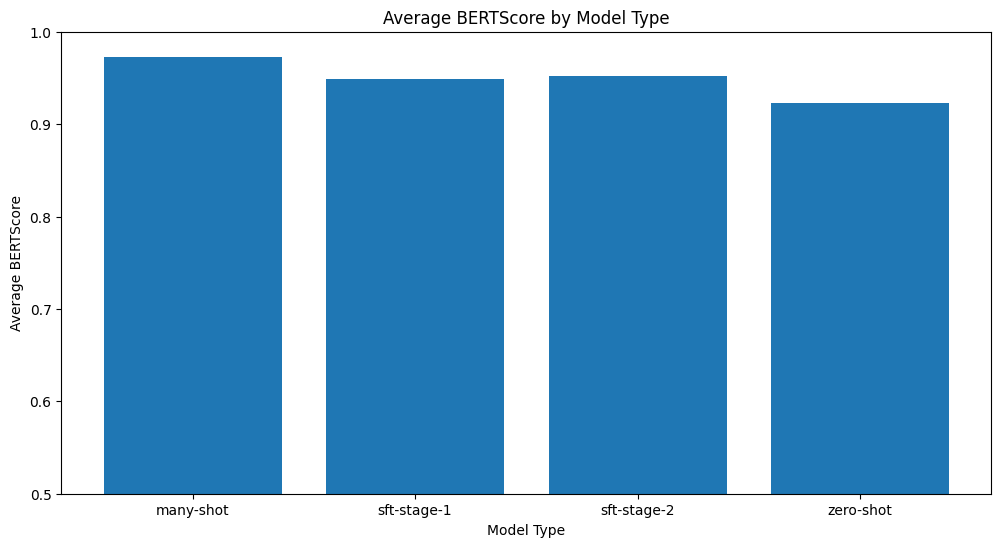

In [12]:
import pandas as pd
from bert_score import BERTScorer
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import os

def calculate_bertscore_batch(candidates, references):
    """
    Calculate BERTScore for batches of translations
    
    Args:
        candidates: List of candidate (generated) translations
        references: List of reference (ground truth) translations
        
    Returns:
        List of F1 scores for each pair
    """
    # Clean special tokens and normalize text
    clean_candidates = []
    clean_references = []
    
    for cand, ref in zip(candidates, references):
        # Process only if both strings are valid
        if isinstance(cand, str) and isinstance(ref, str):
            # Remove <extra_id_X> tokens
            cleaned_cand = re.sub(r'<extra_id_\d+>', '', cand).strip()
            # Add to lists
            clean_candidates.append(cleaned_cand)
            clean_references.append(ref)
        else:
            # Skip invalid pairs
            print(f"Skipping invalid pair: '{cand}' and '{ref}'")
    
    # Initialize the BERTScorer with Indonesian support
    scorer = BERTScorer(lang="id", model_type="xlm-roberta-base", rescale_with_baseline=False)
    
    # Process in smaller batches to avoid memory issues
    batch_size = 32
    all_f1_scores = []
    
    for i in range(0, len(clean_candidates), batch_size):
        batch_cands = clean_candidates[i:i+batch_size]
        batch_refs = clean_references[i:i+batch_size]
        
        try:
            # Calculate scores for this batch
            _, _, f1_scores = scorer.score(batch_cands, batch_refs)
            all_f1_scores.extend(f1_scores.tolist())
        except Exception as e:
            print(f"Error processing batch {i}-{i+batch_size}: {e}")
            # Fall back to zeros for this batch
            all_f1_scores.extend([0.0] * len(batch_cands))
    
    return all_f1_scores

# Process all files
model_scores = {}  # To store average scores per model

for f in glob.glob("./zero-shot/*.csv") + glob.glob("./many-shot/*.csv") + glob.glob("./sft-stage-1/*.csv") + glob.glob("./sft-stage-2/*.csv"):
# go over only files with gemma in the name, across the directories
# for f in glob.glob("./**/gemma*.csv", recursive=True):
    try:
        df = pd.read_csv(f)
        
        # Calculate BERTScore 
        bertscore_results = calculate_bertscore_batch(df['generated'].tolist(), df['ground_truth'].tolist())
        
        # What to do with the vector of scores:
        
        # 1. Add scores to dataframe - each row gets its score
        df['bertscore'] = bertscore_results
        
        # 2. Calculate average score for this file
        avg_bertscore = np.mean(bertscore_results)
        
        # 3. Calculate median and other statistics
        median_bertscore = np.median(bertscore_results)
        min_bertscore = np.min(bertscore_results)
        max_bertscore = np.max(bertscore_results)
        
        # 4. Store model type and file information
        model_type = f.split('/')[1]  # Extract model type from path
        file_name = f.split('/')[-1]  # Extract filename
        
        if model_type not in model_scores:
            model_scores[model_type] = []
        
        model_scores[model_type].append({
            'file': file_name,
            'avg_bertscore': avg_bertscore,
            'median_bertscore': median_bertscore,
            'min_bertscore': min_bertscore, 
            'max_bertscore': max_bertscore
        })
        
        # 5. Save detailed results with per-sentence scores
        # save in bertscore_results directory
        output_dir = 'bertscore_results'
        os.makedirs(output_dir, exist_ok=True)
        output_file = os.path.join(output_dir, f.split('/')[-1].replace('.csv', '_bertscore.csv'))
        df.to_csv(output_file, index=False)
        
        print(f"File: {f}")
        print(f"  - Average BERTScore: {avg_bertscore:.4f}")
        print(f"  - Median BERTScore: {median_bertscore:.4f}")
        print(f"  - Min/Max BERTScore: {min_bertscore:.4f}/{max_bertscore:.4f}")
        
    except Exception as e:
        print(f"Error processing file {f}: {e}")

# Create summary dataframe
all_results = []
for model, files in model_scores.items():
    for file_data in files:
        file_data['model'] = model
        all_results.append(file_data)

summary_df = pd.DataFrame(all_results)
summary_df.to_csv("bertscore_summary.csv", index=False)

# Calculate average per model
model_avg = summary_df.groupby('model')['avg_bertscore'].mean().reset_index()
print("\nModel Average BERTScores:")
print(model_avg)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(model_avg['model'], model_avg['avg_bertscore'])
plt.xlabel('Model Type')
plt.ylabel('Average BERTScore')
plt.title('Average BERTScore by Model Type')
plt.ylim(0.5, 1.0)  # Common BERTScore range
plt.savefig('bertscore_comparison.png')
plt.show()

In [9]:
import pandas as pd
from bert_score import BERTScorer
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

def calculate_bertscore_batch(candidates, references):
    """
    Calculate BERTScore for batches of translations
    
    Args:
        candidates: List of candidate (generated) translations
        references: List of reference (ground truth) translations
        
    Returns:
        List of F1 scores for each pair
    """
    # Clean special tokens and normalize text
    clean_candidates = []
    clean_references = []
    
    for cand, ref in zip(candidates, references):
        # Process only if both strings are valid
        if isinstance(cand, str) and isinstance(ref, str):
            # Remove <extra_id_X> tokens
            cleaned_cand = re.sub(r'<extra_id_\d+>', '', cand).strip()
            # Add to lists
            clean_candidates.append(cleaned_cand)
            clean_references.append(ref)
        else:
            # Skip invalid pairs
            print(f"Skipping invalid pair: '{cand}' and '{ref}'")
    
    # Initialize the BERTScorer with Indonesian support
    scorer = BERTScorer(lang="id", model_type="xlm-roberta-base", rescale_with_baseline=False)
    
    # Process in smaller batches to avoid memory issues
    batch_size = 32
    all_f1_scores = []
    
    for i in range(0, len(clean_candidates), batch_size):
        batch_cands = clean_candidates[i:i+batch_size]
        batch_refs = clean_references[i:i+batch_size]
        
        try:
            # Calculate scores for this batch
            _, _, f1_scores = scorer.score(batch_cands, batch_refs)
            all_f1_scores.extend(f1_scores.tolist())
        except Exception as e:
            print(f"Error processing batch {i}-{i+batch_size}: {e}")
            # Fall back to zeros for this batch
            all_f1_scores.extend([0.0] * len(batch_cands))
    
    return all_f1_scores

/opt/homebrew/Caskroom/miniconda/base/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
try:
        f  = './sft-stage-2/translation_results_aya_32b_finetuned_cot.csv'
        df = pd.read_csv(f)
        
        # Calculate BERTScore 
        bertscore_results = calculate_bertscore_batch(df['generated'].tolist(), df['ground_truth'].tolist())
        
        # What to do with the vector of scores:
        
        # 1. Add scores to dataframe - each row gets its score
        df['bertscore'] = bertscore_results
        
        # 2. Calculate average score for this file
        avg_bertscore = np.mean(bertscore_results)
        
        # 3. Calculate median and other statistics
        median_bertscore = np.median(bertscore_results)
        min_bertscore = np.min(bertscore_results)
        max_bertscore = np.max(bertscore_results)
        
        # 4. Store model type and file information
        model_type = f.split('/')[1]  # Extract model type from path
        file_name = f.split('/')[-1]  # Extract filename
        
        if model_type not in model_scores:
            model_scores[model_type] = []
        
        model_scores[model_type].append({
            'file': file_name,
            'avg_bertscore': avg_bertscore,
            'median_bertscore': median_bertscore,
            'min_bertscore': min_bertscore, 
            'max_bertscore': max_bertscore
        })
        
        # 5. Save detailed results with per-sentence scores
        # save in bertscore_results directory
        output_dir = 'bertscore_results'
        os.makedirs(output_dir, exist_ok=True)
        output_file = os.path.join(output_dir, f.split('/')[-1].replace('.csv', '_bertscore.csv'))
        df.to_csv(output_file, index=False)
        
        print(f"File: {f}")
        print(f"  - Average BERTScore: {avg_bertscore:.4f}")
        print(f"  - Median BERTScore: {median_bertscore:.4f}")
        print(f"  - Min/Max BERTScore: {min_bertscore:.4f}/{max_bertscore:.4f}")
        
except Exception as e:
        print(f"Error processing file {f}: {e}")

Error processing file ./sft-stage-2/translation_results_aya_32b_finetuned_cot.csv: name 'model_scores' is not defined
